In [1]:
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.cm as cm

from astropy.table import unique, Table, join

from numpy.lib.recfunctions import structured_to_unstructured
import fitsio

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

In [2]:
tbl_data = Table.read("data/qnet_ensemble_guadalupe.fits.gz")

In [3]:
def calc_entropy(confidence):
    H = confidence * np.log(confidence) / np.log(2)
    H = np.where(confidence == 0, 0, H)
    return -np.sum(H, axis=1)


In [4]:
confs = structured_to_unstructured(np.asarray(tbl_data["C_NOT", "C_QSO_LZ", "C_QSO_HZ"]))
entropy = calc_entropy(confs)

/tmp/ipykernel_112846/1855944983.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_112846/1855944983.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence) / np.log(2)


In [5]:
tbl_data.add_column(entropy, name="ENTROPY")
tbl_data.sort("ENTROPY", reverse=True)

tbl_data

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.58481870497303
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.5847094057120077
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.583957074455697
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.5826831892554925
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.5822913082988377
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.5820837083687667
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.5812908992306927
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.579862552105281
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.5780194218887367


In [6]:
tbl_tiles = unique(tbl_data, ["TARGETID", "TILEID"])

# Get the unique targetids, and the number of times each appears in the input table
unique_tids, n_occur = np.unique(tbl_tiles["TARGETID"], return_counts=True)

# Get the targetids that appear more than once and then filter
# the table to only keep the targetids that have more than one tileid. 
tids_multi = unique_tids[n_occur > 1] 
tbl_tiles = tbl_tiles[np.isin(tbl_tiles["TARGETID"], tids_multi)]

In [7]:
percentile_cut = 15
bmu_counts = np.bincount(tbl_data["BMU"], minlength=np.max(tbl_data["BMU"]))
good_bmu = bmu_counts > np.percentile(bmu_counts, percentile_cut)
good_idcs = good_bmu[tbl_data["BMU"]]

tbl_reduced = tbl_data[good_idcs]
tbl_reduced

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.58481870497303
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.5847094057120077
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.583957074455697
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.5826831892554925
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.5822913082988377
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.5820837083687667
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.5812908992306927
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.579862552105281
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.5780194218887367


In [8]:
tbl_no_dupe = unique(tbl_reduced, keys="TARGETID")
tbl_no_dupe.sort("ENTROPY", reverse=True)
tbl_no_dupe

TARGETID,TILEID,EXPID,C_NOT,C_QSO_LZ,C_QSO_HZ,BMU,ENTROPY
int64,int64,int64,float64,float64,float64,int64,float64
39633054049765137,1791,88873,0.34,0.33,0.33,740,1.58481870497303
39627703741055635,1083,91171,0.335,0.34,0.325,1185,1.5847094057120077
39627777833441573,1835,93282,0.35,0.33,0.32,878,1.583957074455697
39627753825244495,1841,94986,0.36,0.32,0.32,971,1.5826831892554925
39627709650829350,1120,91063,0.345,0.305,0.35,1113,1.5822913082988377
39632971321314289,2162,88532,0.355,0.305,0.34,879,1.5820837083687667
39633100581374253,1734,89271,0.35,0.3,0.35,374,1.5812908992306927
39627969836092800,2986,97429,0.36,0.345,0.295,418,1.579862552105281
39627946830336921,1848,94622,0.295,0.375,0.33,417,1.5780194218887367


[0.         0.04063638 0.08127275 0.12190913 0.16254551 0.20318189
 0.24381826 0.28445464 0.32509102 0.36572739 0.40636377 0.44700015
 0.48763652 0.5282729  0.56890928 0.60954566 0.65018203 0.69081841
 0.73145479 0.77209116 0.81272754 0.85336392 0.8940003  0.93463667
 0.97527305 1.01590943 1.0565458  1.09718218 1.13781856 1.17845493
 1.21909131 1.25972769 1.30036407 1.34100044 1.38163682 1.4222732
 1.46290957 1.50354595 1.54418233 1.5848187 ]
1.0271612314882417


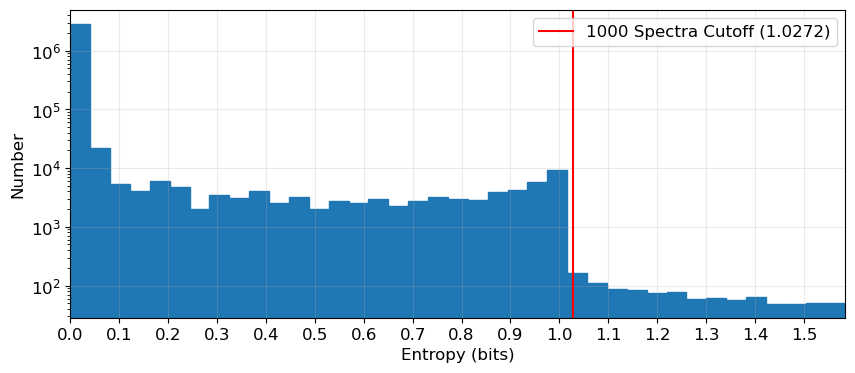

In [9]:
entropy_reduced = tbl_no_dupe["ENTROPY"][:]
bins = np.linspace(0, np.max(entropy_reduced), 40)
# bins = np.arange(0, np.max(entropy_reduced), 0.02)
print(bins)
fig, ax = plt.subplots(figsize=(10, 4))
n, bins, _ = plt.hist(entropy_reduced, bins=bins, ec="C0")
plt.yscale("log")

cutoff = sorted(entropy_reduced)[-1000]
plt.axvline(x = cutoff, c="r", label=f"1000 Spectra Cutoff ({np.round(cutoff, 4)})")
plt.legend()

plt.xlabel("Entropy (bits)")
plt.ylabel("Number")
print(cutoff)
plt.xlim(bins[0], bins[-1])
plt.grid(alpha=0.25)

plt.xticks(np.arange(0, np.max(entropy_reduced), 0.1))
plt.savefig("plots/entropy_dist.pdf", dpi=256, bbox_inches="tight")